# Chatter To Choices: Personalized Stock Recommendations from Social Sentiment

### Contributors:
Cacao, Karl Joseph C.   
Chavez, Miguel Antonio D.   
Libre, Miguel Augustus H.   
Zumel, Jansen Daren C.  

## Problem Statement

Can sparse, explicit, binary StockTwits investor–stock sentiment interactions be used to generate meaningful personalized stock recommendations and inform portfolio optimizer inputs?

## Motivation

Retail investors are increasingly using online brokerages and social-media-type platforms to inform and execute their investment decisions. One such platform featured in this project, Stocktwits, is built around real-time market discussion, sentiment, watchlists, and trending conversations across stocks, ETFs, and crypto. This study was motivated by the possibility of explicit sentiment tags to be levaraged to create personalized, yet reasonably economically viable recommendations for discovery, idea generation, and decision support. The online nature of the retail investment activity also provides an avenue recommenders such as these to be propagated.

## Data Sources

### In the interest of brevity and hygiene, the actual gathering of data from these sources is done in files **scrape_stocktwit.ipynb** and **scrape_yfinance.ipynb**. Refer to those for more detail.
### 1. Stocktwits
StockTwits-from-2008-to-2022 is a large-scale [1], longitudinal implicit-feedback dataset for financial recommendation benchmarking. It provides a complete record of StockTwits posts through 2022, covering more than 7 million active users and over 550 million posts since 2008. At minimum, the released data include anonymous user IDs, message timestamps, message text, ticker mentions, and optional user-declared bullish/bearish sentiment. The repository exposes this information through CSV tables such as symbols (user–message–ticker records), messages (message text), feature_wo_messages (user/timestamp/reply/symbol metadata), and sentiment-focused tables. `The study focuses on records with user-timestamp-symbol-sentiment_tag completed. Sentiment tags explicitly given (bullish/positive or bearish/negative) are treated as binary ratings for the purposes of this project.`
### 2. Wikipedia
Wikipedia is a public, multilingual, large-scale data source comprising article content, hyperlink structure, page metadata, traffic signals, and edit histories. The cited Wikipedia page lists all of the current S&P500 index components in one table [2]. This was scraped to gather the stock market listed symbols for each asset.
### 3. Yahoo Finance (yfinance Unofficial Python API Endoint Wrapper)
Yahoo Finance data was accesed through yfinance, an open-source Python wrapper that provides convenient programmatic access to Yahoo Finance’s publicly available APIs [3]. The library supports retrieval of ticker-level data, bulk downloads, market summaries, search/news results, screening queries, sector and industry information, and live streaming interfaces. `Because yfinance is an unofficial wrapper rather than an officially supported Yahoo Finance developer product, it should be treated as an access library for Yahoo Finance data rather than as an independent primary data source.`

## Methodology

### Overview
This study treats personalized stock recommendation as a collaborative-filtering problem using investor-stock interactions derived from StockTwits messages with explicitly tagged tickers. A sparse user-item utility matrix is used to compare popularity-based, neighborhood-based, and ALS latent-factor recommenders under Monte Carlo cross-validation using NDCG@K, Recall@K, and Diversity@K.

The best-performing recommender is then integrated into a Markowitz portfolio-optimization framework to illustrate practical use, with portfolio performance compared against random allocations through cumulative returns.

### Data Filtering
#### 1. User-Item Interactions
As previously stated, all Stocktwits records with any nulls in user ID, timestamp, symbol, and sentiment tags were filtered out. 
- User ID is necessary to keep persistent identifiers for users and their interactions. 
- Timestamp was initially kept to identify the **latest** interaction of a user with a given item. Only the latest interaction is considered for each user-item interaction.
- Asset symbols were required from each record, as this is the exact attribute that identifies the item with which the user has interacted with.
- Sentiments (bearish or bullish) were binary ratings of a user towards their opinion on an an asset's performance. `As previously stated, the Stocktwits platform allows users to explicitly include these in each message.` It is not derived from text signals in the message.
#### 2. Item Scope
A key challenge with the dataset was the sparsity of the matrix. It is the assumption of the proponents that the largest market-cap assets traded in the New-York Stock Exchange would have some of the most interacted-with items in the dataset. As such, only messages that contained at least one symbol from any S&P500 components were kept. Even then, only 473 of the 503 components in the S&P500 index had at least one interaction in the dataset. This is attributed to the fact that some of those listed may not have yet been known or even founded by the end of the dataset's cut-off date. Given that, Sparsity was at ~99.13%.
#### 3. Returns Data for Portfolio Generation
Daily returns were then computed using percentage changes in closing prices on a per-ticker basis. Because the first return of each series is undefined, rows containing missing return values are removed. 
#### 4. On the Exclusion of Messages
`As this is not a sentiment analysis study in the classic sense of quantifying positive or negative sentiments from text data, the actual messages attached to each Stocktwits record corresponding to the original platform post is not included in the scope to reduce memory complexity. Using the messages to derive sentiment would have been a form of implicit rating, and is out of scope for this study.`


### Data Preprocessing
The preprocessing pipeline produces two aligned inputs:  
(1) a sparse user-item utility matrix from StockTwits sentiment data, and  
(2) a daily asset-returns matrix from S\&P 500 price data.

#### 1. Interaction extraction and matrix construction
Raw StockTwits data are reduced to investor ID, asset ticker, and sentiment label. Explicit bullish tags are encoded as $1.0$, explicit bearish tags as $0.0$, and all other cases as missing, yielding

$$
R = \{r_{ui}\}_{u=1,i=1}^{U,I},
$$

where $r_{ui}=1$ denotes a bullish interaction, $r_{ui}=0$ a bearish interaction, and $r_{ui}=\mathrm{NaN}$ no observed interaction. Missing values are preserved as unobserved rather than treated as negative preference.

`Only assets included in the S&P 500 price data were included as items in the utility matrix`

#### 2. Market-price preprocessing
S\&P 500 price data are cleaned separately to form a daily returns matrix. Dates are parsed, the benchmark index $\hat{\text{GSPC}}$ is excluded from the investable universe, and closing prices are converted into simple returns:

$$
r_{i,t} = \frac{P_{i,t} - P_{i,t-1}}{P_{i,t-1}}.
$$

The cleaned data are then pivoted into a date-by-ticker matrix for optimization and benchmarking.

#### 3. Holdout generation and evaluation setup
Recommendation quality is evaluated through Monte Carlo cross-validation with repeated random holdout splits. For each seed, users with enough positive interactions are eligible, and a fraction of each user's bullish assets is withheld for testing. If

$$
\mathcal{P}_u = \{ i : r_{ui} = 1 \},
$$

then the holdout set $\mathcal{H}_u \subseteq \mathcal{P}_u$ is sampled such that

$$
|\mathcal{H}_u| = \max\left(1, \left\lfloor \text{test\_frac} \cdot |\mathcal{P}_u| \right\rfloor \right).
$$

During evaluation, only items unobserved in training are recommendable:

$$
\mathcal{C}_u = \{ i : r^{\text{train}}_{ui} \text{ is missing} \}.
$$

#### 4. Model-specific preprocessing and portfolio link
For neighborhood-based collaborative filtering, missing values are temporarily filled with zeros for cosine-similarity computation, while original missingness is preserved for recommendation masking. Diversity is measured from an item-item similarity matrix derived from the training data:

$$
\mathrm{Diversity@K}(L_u) = 1 - \frac{1}{\binom{K}{2}} \sum_{i < j,\; i,j \in L_u} S(i,j).
$$

After evaluation, the best recommender is aligned to the same ticker universe as the returns matrix so that its outputs can be translated into investor views for the portfolio stage.
  
### Summary
Overall, preprocessing converts StockTwits sentiment data into a recommendation dataset with explicit train-test separation and prepares aligned return data for portfolio construction. This enables fair recommender comparison and downstream integration with Markowitz optimization.

### Evaluation Methodology
This study evaluates recommendation quality using repeated Monte Carlo holdout splits on the user-item utility matrix. For each random seed, the same train-test split is used for all recommenders so that Popularity, User-User, Item-Item, and ALS are compared on an identical ranking task.

#### 1. Holdout construction
For each seed, a user-level holdout is created by randomly masking a fraction of observed bullish interactions from eligible users. Only users with at least two positive interactions are considered, and approximately 20\% of each eligible user's bullish assets are withheld:

$$
\mathcal{P}_u = \{ i : r_{ui} = 1 \}, \qquad
|\mathcal{H}_u| = \max\left(1,\left\lfloor 0.2 \cdot |\mathcal{P}_u| \right\rfloor\right).
$$

The retained observations form the training matrix, while the hidden bullish interactions form the test set.

#### 2. Common ranking setup
All models recommend only assets that are unobserved in the training matrix:

$$
\mathcal{C}_u = \{ i : r_{ui}^{\text{train}} \text{ is missing} \}.
$$

This same candidate set is used for every recommender. Popularity ranks assets by training-set popularity, User-User uses cosine \(k\)-nearest-neighbor neighborhoods, Item-Item uses cosine item similarity with top-\(k\) pruning, and ALS ranks assets using latent scores from $UV^\top$.

#### 3. Tie-break
Without a robust way to justify tie-breakers, alphabetic ordering of the asset's symbols were used to break ties in recommendation rankings.


#### 4. Metric calculation and aggregation
For each user in each Monte Carlo split, every recommender produces a ranked list over the same unseen candidate set. From this list, NDCG@50, Recall@50, and Diversity@50 are computed at the user level. These user-level values are then averaged within each split to obtain one seed-level score per model, and the final reported results are the mean and standard deviation of those seed-level scores across all random seeds.

**NDCG@50.**  
For each user, the recommender's ranked list is matched against the held-out test items, where only hidden bullish assets are treated as relevant. Let the resulting relevance vector be

$$
\mathrm{rel}_u = (rel_{u1}, rel_{u2}, \dots).
$$

Discounted Cumulative Gain is computed as

$$
\mathrm{DCG@50}_u
=
\sum_{j=1}^{50}
\frac{rel_{uj}}{\log_2(j+1)}.
$$

This is normalized by the Ideal DCG, computed by placing all of that user's held-out relevant items first within the same candidate set:

$$
\mathrm{NDCG@50}_u
=
\frac{\mathrm{DCG@50}_u}{\mathrm{IDCG@50}_u}.
$$

If a user has no relevant held-out item, the value is treated as missing. The model's seed-level NDCG@50 is the mean of valid user-level NDCG@50 values.

**Recall@50.**  
Recall is computed from the same ranked relevance vector:

$$
\mathrm{Recall@50}_u
=
\frac{\text{number of held-out relevant items appearing in the top 50}}
{\text{total number of held-out relevant items for user } u}.
$$

Because the test set contains only held-out positive interactions, the denominator is simply the number of hidden bullish assets for that user. Users with no held-out positive item are excluded, and the seed-level Recall@50 is the mean across valid users.

**Diversity@50.**  
Diversity is computed from the top-50 recommended items regardless of relevance. Using an item-item cosine similarity matrix derived from the training data, intra-list diversity is defined as

$$
\mathrm{Diversity@50}(L_u)
=
1 - \frac{1}{\binom{50}{2}}
\sum_{i<j,\; i,j \in L_u} S(i,j),
$$

where \(S(i,j)\) is the similarity between recommended assets \(i\) and \(j\). Higher values indicate less redundancy within the recommendation list. If fewer than two items are recommended, diversity is set to \(0\). The seed-level Diversity@50 is the mean of user-level diversity values.

**Aggregate reporting.**  
Aggregation is therefore done in two stages:

1. compute user-level NDCG@50, Recall@50, and Diversity@50 for each recommender within one split, then average across users to obtain one seed-level score per metric;  
2. repeat across random seeds, then report the overall mean and standard deviation of the seed-level scores for each model.

This means the final tables summarize repeated user-level averages across multiple holdout splits, rather than results from only one partition.

#### Addendum:
To illustrate applicability of recommendations, the resulting portfolios were evaluated.   

For a single out-of-sample window, the optimized Black-Litterman portfolio was constructed on the investor’s top-N recommended assets, with the prior covariance matrix estimated using the Ledoit-Wolf shrinkage estimator on the training return matrix. Its realized cumulative return was then compared against the empirical distribution of many Dirichlet-randomized long-only portfolios generated on the same asset universe and evaluated over the same test window.


### Note:
Any steps whose execution is unclear from the code could be using functions from any of the following modules or notebooks: 
- scrape_stocktwit.ipynb
- scrape_yfinance.ipynb
- data_prep.py
- utils.py
- black_litterman_recommender.py
- markowitz_analysis.py
- markowitz_plots.py

## Results and Discussion

###

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import black_litterman_recommender as blr
import importlib
from concurrent.futures import ThreadPoolExecutor, as_completed
importlib.reload(blr)
import utils as ut
import data_prep
import markowitz_analysis as ma
import markowitz_plots as mp

In [3]:
df = pd.read_csv('cleaned_ratings.csv', index_col=0)
stock_data_df, stock_data, stock_prices, returns_matrix = data_prep.load_sp500_data("sp500long.csv")

util = blr.stocktwits_to_sentiment_matrix(
    df,
    user_col = "user_id",
    asset_col = "symbol_list",
    sentiment_col = "sentiment",
    bullish_values = (1, "bullish", "Bullish", "BULLISH"),
    bearish_values = (-1,"bearish", "Bearish", "BEARISH"),
)

util = util[returns_matrix.columns.intersection(util.columns)]

In [10]:
sparsity = (1 - util.notna().sum().sum() / util.size) * 100
print(f"{sparsity:.2f}%")

99.13%


In [8]:
U, V, _ = blr.als_explicit(util, 8, lam=0.1, max_iter=50, tol=1e-4, seed=42)

In [9]:
seeds = [42, 67, 69, 1337, 420]

res = blr.evaluate_recommenders_parallel(
    util=util,
    U=U,
    V=V,
    seeds=seeds,
    k=50,
    top_k_neighbors=25,
    max_workers=8,
    backend="process",
)

df_ndcg = res["tables"]["ndcg"]
df_recall = res["tables"]["recall"]
df_diversity = res["tables"]["diversity"]

summary_ndcg = res["summary"]["ndcg"]
summary_recall = res["summary"]["recall"]
summary_diversity = res["summary"]["diversity"]
summary_all = res["summary"]["combined"]

# print(df_ndcg.round(4))
# print(df_recall.round(4))
# print(df_diversity.round(4))
# print(summary_all.round(4))

In [1]:
means_df = pd.DataFrame({
    "NDCG@50": summary_ndcg["Mean NDCG@10"],
    "Recall@50": summary_recall["Mean Recall@10"],
    "Diversity@50": summary_diversity["Mean Diversity@10"],
}).T

stds_df = pd.DataFrame({
    "NDCG@50": summary_ndcg["Std NDCG@10"],
    "Recall@50": summary_recall["Std Recall@10"],
    "Diversity@50": summary_diversity["Std Diversity@10"],
}).T

x = np.arange(len(means_df.index))
n_models = len(means_df.columns)
width = 0.2

fig, ax = plt.subplots(figsize=(10, 6))

for i, col in enumerate(means_df.columns):
    ax.bar(
        x + (i - (n_models - 1) / 2) * width,
        means_df[col].values,
        width=width,
        yerr=stds_df[col].values,
        capsize=4,
        label=col,
    )

ax.set_title("Recommender Performance Across Metrics")
ax.set_xlabel("Metric")
ax.set_ylabel("Score")
ax.set_xticks(x)
ax.set_xticklabels(means_df.index)
ax.legend(title="Recommender")
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

NameError: name 'pd' is not defined

In [34]:
investor_id = 5

In [35]:
recs, scores = blr.recommend_from_als(util, U, V, investor_id, top_n=10)

In [36]:
stock_data_df, stock_data, stock_prices, returns_matrix = data_prep.load_sp500_data("sp500long.csv")

,als_score
symbol_list,
BALL,1.171876
ALL,1.164815
RCL,1.161166
CHTR,1.142511
FAST,1.134490
FIS,1.132104
GDDY,1.129072
ES,1.115484
J,1.104176


,Metric,Value
0,Optimized cumulative return,0.114910
1,Random mean cumulative return,0.035666
2,Random std cumulative return,0.033641
3,Optimized percentile vs random,98.460000


,long_asset,short_asset,score_long,score_short,score_gap,q_view,confidence,omega_diag
0,BALL,HD,1.171876,1.041577,0.130300,0.000119,0.898148,3.578009e-07
1,ALL,ALLE,1.164815,1.036730,0.128085,0.000119,0.897936,4.122568e-07
2,RCL,WMB,1.161166,1.035814,0.125352,0.000119,0.897641,7.056087e-07


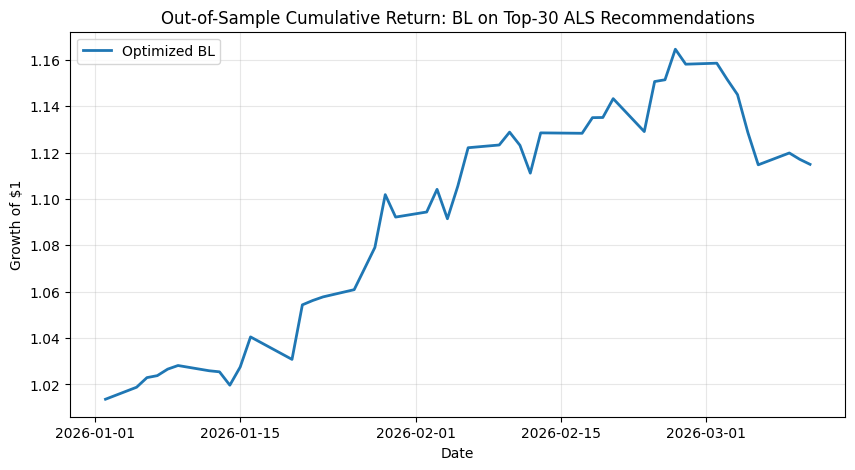

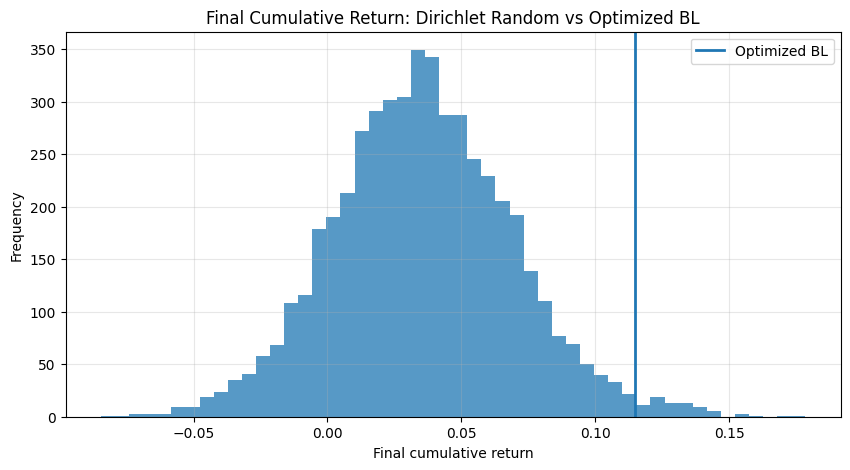

In [44]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.covariance import LedoitWolf

import utils as ut
import markowitz_analysis as ma
import black_litterman_recommender as blr

# ------------------------------------------------------------
# Assumes these already exist in the notebook:
# stock_data, returns_matrix, util, U, V, investor_id, N
# ------------------------------------------------------------

end_date = "2026-01-01"
start_date = "2024-01-01"
risk_free_daily = 0.04 / 252
tau = 0.01
view_return_scale = 0.03 / 252
n_random = 5000
seed = 42
top_n = 30
n_views = top_n//10  # e.g. 5 views for top-50

# 1) investor-specific top-N recommendation universe from existing ALS outputs
rec_scores = blr.investor_recommender_scores_als(
    M=util,
    U=U,
    V=V,
    investor_id=investor_id,
    assets=pd.Index(util.columns.astype(str)),
    exclude_observed=True,
).dropna()

top_assets = pd.Index(rec_scores.head(top_n).index.astype(str))
if len(top_assets) < 2:
    raise ValueError("Not enough recommended unseen assets in the top-N universe.")

display(rec_scores.head(top_n).rename("als_score").to_frame())

# 2) train/test split on that restricted universe
returns_sub = returns_matrix.reindex(columns=top_assets)
returns_sub = returns_sub.loc[start_date:].dropna(how="all", axis=1)
raw = ma.fit_raw_markowitz(
    returns_matrix=returns_sub,
    stock_data=stock_data,
    end_date=end_date,
    risk_free=risk_free_daily,
    num_random=0,
)

# 3) Ledoit-Wolf covariance prior from training returns
sigma_prior = LedoitWolf().fit(raw.R_train).covariance_

# 4) build BL views directly from existing ALS scores
scores_sub = rec_scores.reindex(raw.tickers).dropna()

P, Q, Omega, view_table = blr.build_relative_views_from_scores(
    scores=scores_sub,
    tickers=raw.tickers,
    sigma_prior=sigma_prior,
    tau=tau,
    n_views=n_views,
    view_return_scale=view_return_scale,
)

posterior_mu, posterior_sigma = blr.black_litterman_posterior(
    prior_mu=raw.mu_train,
    sigma_prior=sigma_prior,
    P=P,
    Q=Q,
    Omega=Omega,
    tau=tau,
)

# 5) optimized portfolio weights (max-Sharpe)
_, _, weights_bl = ut.min_vol_max_sharpe(
    posterior_mu,
    posterior_sigma,
    len(raw.tickers),
    raw.returns_train,
    risk_free_rate=risk_free_daily,
)

w_opt = weights_bl[1]  # [0] min-vol, [1] max-Sharpe

# 6) optimized out-of-sample cumulative return
returns_test = raw.returns_test.reindex(columns=raw.tickers).dropna(how="any")
cum_opt, ret_opt = ut.compute_portfolio_cumret(w_opt, returns_test)
opt_final = float(cum_opt.iloc[-1] - 1.0)

# 7) Dirichlet-random benchmark on exact same universe / window
rng = np.random.default_rng(seed)
rand_final = []

for w in rng.dirichlet(np.ones(len(raw.tickers)), size=n_random):
    w_rand = pd.Series(w, index=raw.tickers)
    cum_rand, _ = ut.compute_portfolio_cumret(w_rand, returns_test)
    rand_final.append(float(cum_rand.iloc[-1] - 1.0))

rand_final = pd.Series(rand_final, name="random_cum_return")
pctile = 100 * (rand_final <= opt_final).mean()

summary = pd.DataFrame({
    "Metric": [
        "Optimized cumulative return",
        "Random mean cumulative return",
        "Random std cumulative return",
        "Optimized percentile vs random",
    ],
    "Value": [
        opt_final,
        rand_final.mean(),
        rand_final.std(ddof=1),
        pctile,
    ],
})

display(summary)
display(view_table)

# 8) returns-only plots
plt.figure(figsize=(10, 5))
plt.plot(cum_opt.index, cum_opt.values, linewidth=2, label="Optimized BL")
plt.title(f"Out-of-Sample Cumulative Return: BL on Top-{top_n} ALS Recommendations")
plt.xlabel("Date")
plt.ylabel("Growth of $1")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

plt.figure(figsize=(10, 5))
plt.hist(rand_final.dropna(), bins=50, alpha=0.75)
plt.axvline(opt_final, linewidth=2, label="Optimized BL")
plt.title(f"Final Cumulative Return: Dirichlet Random vs Optimized BL")
plt.xlabel("Final cumulative return")
plt.ylabel("Frequency")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()